## Env. Verification & Imports

In [2]:
# === Environment Verification ===
# Confirms all dependencies are installed and accessible

import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt
import pandas as pd
import control

print(f"NumPy:          {np.__version__}")
print(f"SciPy:          {signal.__name__} (loaded)")
print(f"matplotlib:     {plt.matplotlib.__version__}")
print(f"pandas:         {pd.__version__}")
print(f"python-control: {control.__version__}")
print("\nAll dependencies loaded successfully.")

NumPy:          2.4.4
SciPy:          scipy.signal (loaded)
matplotlib:     3.10.9
pandas:         3.0.2
python-control: 0.10.2

All dependencies loaded successfully.


## 1. Powertrain Model

In [3]:
import numpy as np
import control

class PowertrainModel:
    """
    Simplified powertrain model using a first-order linear transfer function.

    Represents the relationship between throttle position (input) and engine
    torque (output) as T(s) = K / (τs + 1). This is a deliberate simplification —
    real engines are nonlinear with higher-order dynamics, but a first-order model
    captures the essential rise behavior needed to study how sensor imperfections
    affect closed-loop control.

    The transfer_function field stores a control.TransferFunction object for
    standalone analysis and verification. The actual step-by-step simulation
    uses the exact analytical discretization to avoid unnecessary overhead.
    """

    def __init__(self, gain=200.0, time_constant=0.5):
        """
        Initialize the powertrain model and create the transfer function.

        Parameters:
            gain (float): Steady-state gain K in Nm. Represents the final torque
                          output for a unit throttle input. Default: 200.0
            time_constant (float): Time constant τ in seconds. Controls how
                                   quickly the engine responds to throttle
                                   changes. Default: 0.5
        """
        self.gain = gain
        self.time_constant = time_constant

        # Create the continuous-time transfer function T(s) = K / (τs + 1)
        # Numerator: [K], Denominator: [τ, 1]
        self.transfer_function = control.TransferFunction(
            [self.gain],
            [self.time_constant, 1]
        )

        # Current torque output — starts at zero (engine at rest)
        self.current_output = 0.0

    def simulate_step(self, input_signal, dt):
        """
        Advance the powertrain model by one time step using the exact
        analytical solution for a first-order system under zero-order hold.

        The formula y[k+1] = y[k] * exp(-dt/τ) + K * (1 - exp(-dt/τ)) * u[k]
        is mathematically exact for constant input over the interval dt.

        Parameters:
            input_signal (float): Current throttle input from the controller.
            dt (float): Simulation time step in seconds.

        Returns:
            float: Updated torque output after this time step.
        """
        # Decay factor — how much the system "remembers" from the previous step
        decay = np.exp(-dt / self.time_constant)

        # Update: blend of decaying old output and new input contribution
        self.current_output = (
            self.current_output * decay
            + self.gain * (1 - decay) * input_signal
        )

        return self.current_output

    def get_output(self):
        """
        Return the current torque output without advancing the simulation.

        Returns:
            float: Current torque output in Nm.
        """
        return self.current_output

    def reset(self):
        """
        Reset the model state to initial conditions (engine at rest).
        Called between simulation runs to ensure a clean starting state.
        """
        self.current_output = 0.0

### 1.1 Powertrain Model Verification

Check 1 — Steady-state output: 199.9909 Nm (expected: 200.0)
Check 2 — Output at t=τ:        126.5711 Nm (expected: 126.4241)


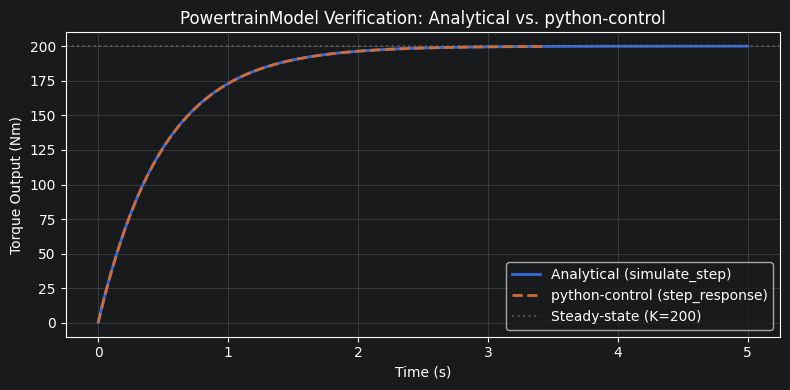


Steady-state error: 0.009080 Nm
Time-constant error: 0.147005 Nm

Verification PASSED


In [4]:
# === PowertrainModel Verification ===
# Three checks to confirm the model matches T(s) = K / (τs + 1) behavior.

# --- Setup ---
plant = PowertrainModel(gain=200.0, time_constant=0.5)
dt = 0.001  # 1 ms time step — fine enough for accurate results
duration = 5.0  # seconds — long enough to reach steady state
steps = int(duration / dt)

# --- Run a step response: apply a constant unit input ---
time_history = []
output_history = []

for i in range(steps):
    t = i * dt
    plant.simulate_step(1.0, dt)  # unit throttle input
    time_history.append(t)
    output_history.append(plant.get_output())

time_array = np.array(time_history)
output_array = np.array(output_history)

# --- Check 1: Steady-state value should approach K (200 Nm) ---
steady_state = output_array[-1]
print(f"Check 1 — Steady-state output: {steady_state:.4f} Nm (expected: 200.0)")

# --- Check 2: At t = τ (0.5s), output should be ~63.2% of final value ---
tau_index = int(plant.time_constant / dt)
output_at_tau = output_array[tau_index]
expected_at_tau = plant.gain * (1 - np.exp(-1))  # K * 0.6321
print(f"Check 2 — Output at t=τ:        {output_at_tau:.4f} Nm (expected: {expected_at_tau:.4f})")

# --- Check 3: Compare against python-control step response ---
ctrl_time, ctrl_output = control.step_response(plant.transfer_function)
# Scale by K since control.step_response gives the unit step response
# which already accounts for the gain in the transfer function

# Plot both responses on top of each other
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(time_array, output_array, label='Analytical (simulate_step)', linewidth=2)
ax.plot(ctrl_time, ctrl_output, '--', label='python-control (step_response)', linewidth=2)
ax.axhline(y=200.0, color='gray', linestyle=':', alpha=0.5, label='Steady-state (K=200)')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Torque Output (Nm)')
ax.set_title('PowertrainModel Verification: Analytical vs. python-control')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Summary ---
ss_error = abs(steady_state - plant.gain)
tau_error = abs(output_at_tau - expected_at_tau)
print(f"\nSteady-state error: {ss_error:.6f} Nm")
print(f"Time-constant error: {tau_error:.6f} Nm")
print(f"\nVerification {'PASSED' if ss_error < 0.1 and tau_error < 0.5 else 'FAILED'}")

## 2. PID Controller

In [5]:
class PIDController:
    """
    Discrete PID controller for torque regulation in the CFMOSCPTCS framework.

    Implements the standard Proportional-Integral-Derivative control law in
    discrete time. The controller compares the desired torque (setpoint) to
    the measured torque (which may be corrupted by sensor imperfections),
    computes an error signal, and generates a throttle control output.

    Includes output clamping and integral anti-windup to prevent unrealistic
    behavior when the control signal saturates. This is standard practice
    in real PID implementations — without it, the integral term accumulates
    unbounded error during saturation and causes severe overshoot on recovery.

    Gains are intended to be tuned via Ziegler-Nichols as specified in PR2.
    """

    def __init__(self, kp, ki, kd, setpoint, output_min=0.0, output_max=1.0):
        """
        Initialize the PID controller with gains and setpoint.

        Parameters:
            kp (float): Proportional gain — reacts to current error.
            ki (float): Integral gain — corrects accumulated past error.
            kd (float): Derivative gain — dampens based on error rate of change.
            setpoint (float): Desired torque value in Nm.
            output_min (float): Minimum control output (throttle floor). Default: 0.0
            output_max (float): Maximum control output (throttle ceiling). Default: 1.0
        """
        self.kp = kp
        self.ki = ki
        self.kd = kd
        self.setpoint = setpoint
        self.output_min = output_min
        self.output_max = output_max

        # Internal state — accumulated and previous error for I and D terms
        self.integral_error = 0.0
        self.previous_error = 0.0

    def compute(self, measured_value, dt):
        """
        Compute the control output based on the current measured value.

        Uses the discrete PID formula:
            P = Kp * error
            I = Ki * (integral of error over time)
            D = Kd * (change in error / dt)

        Anti-windup: the integral term only accumulates when the output
        is not saturated, preventing windup during prolonged error.

        Parameters:
            measured_value (float): Current torque measurement (possibly
                                    corrupted by sensor imperfections).
            dt (float): Time step in seconds.

        Returns:
            float: Clamped control signal for the powertrain model.
        """
        # Current error — how far the measurement is from the target
        error = self.setpoint - measured_value

        # Proportional term — immediate response to current error
        p_term = self.kp * error

        # Integral term — accumulated error over time (rectangular integration)
        # Tentatively accumulate, but we may roll it back if output saturates
        tentative_integral = self.integral_error + error * dt
        i_term = self.ki * tentative_integral

        # Derivative term — rate of change of error
        # On the first call, previous_error is 0, so the first derivative
        # kick is expected and settles immediately
        d_term = self.kd * (error - self.previous_error) / dt

        # Raw (unclamped) control output
        raw_output = p_term + i_term + d_term

        # Clamp the output to valid throttle range
        clamped_output = np.clip(raw_output, self.output_min, self.output_max)

        # Anti-windup: only commit the integral update if output is not saturated
        if raw_output == clamped_output:
            # Output within bounds — safe to accumulate
            self.integral_error = tentative_integral
        # else: output was clipped, so we freeze the integral to prevent windup

        # Store current error for next step's derivative calculation
        self.previous_error = error

        return clamped_output

    def reset(self):
        """
        Reset internal error accumulators to zero.
        Called between simulation runs for a clean starting state.
        """
        self.integral_error = 0.0
        self.previous_error = 0.0

    def set_setpoint(self, new_setpoint):
        """
        Update the desired torque value.

        Parameters:
            new_setpoint (float): New target torque in Nm.
        """
        self.setpoint = new_setpoint

### 2.1 PID Controller Verification

Check 1 — Final output: 199.9908 Nm (setpoint: 200.0)
          Steady-state error: 0.0092 Nm
Check 2 — Control signal range: [0.9983, 1.0000] (clamped: True)
Check 3 — Settled within 2% band: True


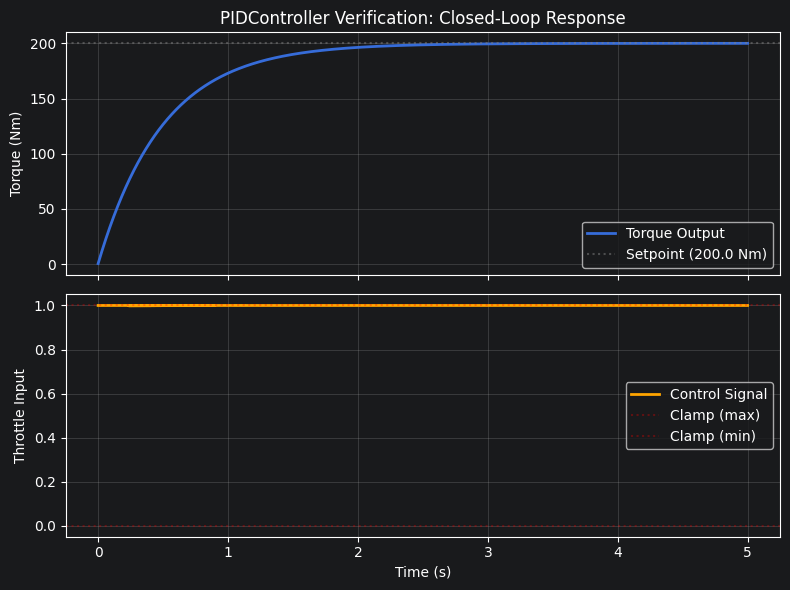


Verification PASSED


In [6]:
# === PIDController Verification ===
# Closed-loop test: PID controller driving the PowertrainModel to a setpoint.
# Verifies that the controller reaches the target, stays within clamp bounds,
# and stabilizes without sustained oscillation.

# --- Setup ---
plant = PowertrainModel(gain=200.0, time_constant=0.5)
setpoint = 200.0  # Nm — target torque

# Conservative PID gains for initial verification
# These are not Ziegler-Nichols tuned yet — just reasonable starting values
pid = PIDController(kp=0.01, ki=0.02, kd=0.001, setpoint=setpoint)

dt = 0.001
duration = 5.0
steps = int(duration / dt)

time_history = []
output_history = []
control_history = []

for i in range(steps):
    t = i * dt

    # Measure the plant output (clean feedback — no sensor model yet)
    measured = plant.get_output()

    # PID computes the control signal
    control_signal = pid.compute(measured, dt)

    # Control signal drives the plant forward one step
    plant.simulate_step(control_signal, dt)

    time_history.append(t)
    output_history.append(plant.get_output())
    control_history.append(control_signal)

time_array = np.array(time_history)
output_array = np.array(output_history)
control_array = np.array(control_history)

# --- Check 1: Does the output reach the setpoint? ---
final_output = output_array[-1]
ss_error = abs(final_output - setpoint)
print(f"Check 1 — Final output: {final_output:.4f} Nm (setpoint: {setpoint})")
print(f"          Steady-state error: {ss_error:.4f} Nm")

# --- Check 2: Is the control signal always within [0, 1]? ---
ctrl_min = control_array.min()
ctrl_max = control_array.max()
clamped = ctrl_min >= 0.0 and ctrl_max <= 1.0
print(f"Check 2 — Control signal range: [{ctrl_min:.4f}, {ctrl_max:.4f}] (clamped: {clamped})")

# --- Check 3: Does the system settle? ---
# Check if the last 10% of the output stays within 2% of the setpoint
settle_window = output_array[int(0.9 * steps):]
within_band = np.all(np.abs(settle_window - setpoint) < 0.02 * setpoint)
print(f"Check 3 — Settled within 2% band: {within_band}")

# --- Plot: Torque response and control signal ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# Torque response
ax1.plot(time_array, output_array, label='Torque Output', linewidth=2)
ax1.axhline(y=setpoint, color='gray', linestyle=':', alpha=0.5, label=f'Setpoint ({setpoint} Nm)')
ax1.set_ylabel('Torque (Nm)')
ax1.set_title('PIDController Verification: Closed-Loop Response')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Control signal
ax2.plot(time_array, control_array, color='orange', label='Control Signal', linewidth=2)
ax2.axhline(y=1.0, color='red', linestyle=':', alpha=0.3, label='Clamp (max)')
ax2.axhline(y=0.0, color='red', linestyle=':', alpha=0.3, label='Clamp (min)')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Throttle Input')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Summary ---
passed = ss_error < 1.0 and clamped and within_band
print(f"\nVerification {'PASSED' if passed else 'FAILED'}")

## 3. Sensor Model

In [7]:
class SensorModel:
    """
    Sensor imperfection model for the CFMOSCPTCS framework.

    Simulates five types of realistic sensor imperfections that corrupt the
    feedback signal between the powertrain output and the PID controller.
    Each imperfection is individually controllable — setting a parameter to
    its neutral value (0 for noise/bias/drift, dt for sampling period, 0 for
    delay steps) effectively disables that imperfection.

    Imperfections are applied in physically correct order:
        1. Signal delay (transport delay in communication path)
        2. Sampling (zero-order hold at discrete intervals)
        3. Noise + bias + drift (sensor hardware corruptions)

    Models are grounded in sensor characterization literature:
        - El-Sheimy et al. (2008) for stochastic noise components
        - Romero Segovia et al. (2014) for noise effects on PID performance
    """

    def __init__(self, noise_std=0.0, bias=0.0, drift_rate=0.0,
                 sampling_period=0.001, delay_steps=0):
        """
        Initialize the sensor model with imperfection parameters.

        Parameters:
            noise_std (float): Standard deviation σ of additive Gaussian noise.
                               0 = no noise. Units match the signal (Nm).
            bias (float): Constant offset b added to every reading.
                          0 = no bias. Units match the signal (Nm).
            drift_rate (float): Linear drift rate d in Nm/s. The drift
                                contribution grows as d * t over time.
                                0 = no drift.
            sampling_period (float): Time T between sensor samples in seconds.
                                     Between samples, the last reading is held
                                     (zero-order hold). Default: 0.001 (1 ms,
                                     effectively continuous at typical dt).
            delay_steps (int): Number of time steps of pure transport delay.
                               0 = no delay. The actual delay duration is
                               delay_steps * dt seconds.
        """
        self.noise_std = noise_std
        self.bias = bias
        self.drift_rate = drift_rate
        self.sampling_period = sampling_period
        self.delay_steps = delay_steps

        # Zero-order hold state — tracks when the last sample was taken
        # and what value is currently being held
        self.last_sample_time = -np.inf  # Forces an immediate sample on first call
        self.held_value = 0.0

        # Delay buffer — stores past signal values for transport delay.
        # Initialized with zeros; length is delay_steps + 1 to hold the
        # current value plus all delayed values.
        self.delay_buffer = [0.0] * (self.delay_steps + 1)

    def apply(self, true_value, current_time):
        """
        Take the true signal and return the corrupted sensor measurement
        with all imperfections applied in physically correct order.

        Order of application:
            1. Delay — retrieve the value from delay_steps ago
            2. Sampling — apply zero-order hold at the sampling period
            3. Noise + Bias + Drift — additive sensor corruptions

        Parameters:
            true_value (float): The actual torque output from the powertrain
                                model (before any sensor corruption).
            current_time (float): Current simulation time in seconds.

        Returns:
            float: Corrupted sensor measurement as seen by the PID controller.
        """
        # --- Stage 1: Signal Delay ---
        # Push the current true value into the buffer and pull out the
        # delayed value from delay_steps ago
        self.delay_buffer.append(true_value)
        delayed_value = self.delay_buffer.pop(0)

        # --- Stage 2: Zero-Order Hold Sampling ---
        # Only update the held value if enough time has passed since
        # the last sample. Otherwise, keep holding the previous reading.
        if current_time - self.last_sample_time >= self.sampling_period:
            self.held_value = delayed_value
            self.last_sample_time = current_time

        sampled_value = self.held_value

        # --- Stage 3: Additive Corruptions ---
        # Noise: random draw from N(0, σ²) — different every call
        noise = np.random.normal(0.0, self.noise_std) if self.noise_std > 0 else 0.0

        # Bias: constant offset — same every call
        # Drift: linear ramp that grows with time — d * t
        corrupted = sampled_value + noise + self.bias + (self.drift_rate * current_time)

        return corrupted

    def reset(self):
        """
        Reset internal state for a fresh simulation run.
        Clears the delay buffer and resets the zero-order hold.
        """
        self.last_sample_time = -np.inf
        self.held_value = 0.0
        self.delay_buffer = [0.0] * (self.delay_steps + 1)

### 3.1 Sensor Model Verification

Test 1 — Noise: measured std=5.498 (expected ≈5.0)
Test 2 — Bias: measured mean=109.950 (expected 110.0)
Test 3 — Drift: final=109.995 (expected ≈109.995)
Test 4 — Sampling: 20 unique values over 2000 steps (expected ≈20)
Test 5 — Delay: signal appears at t=0.551s (expected ≈0.550s)


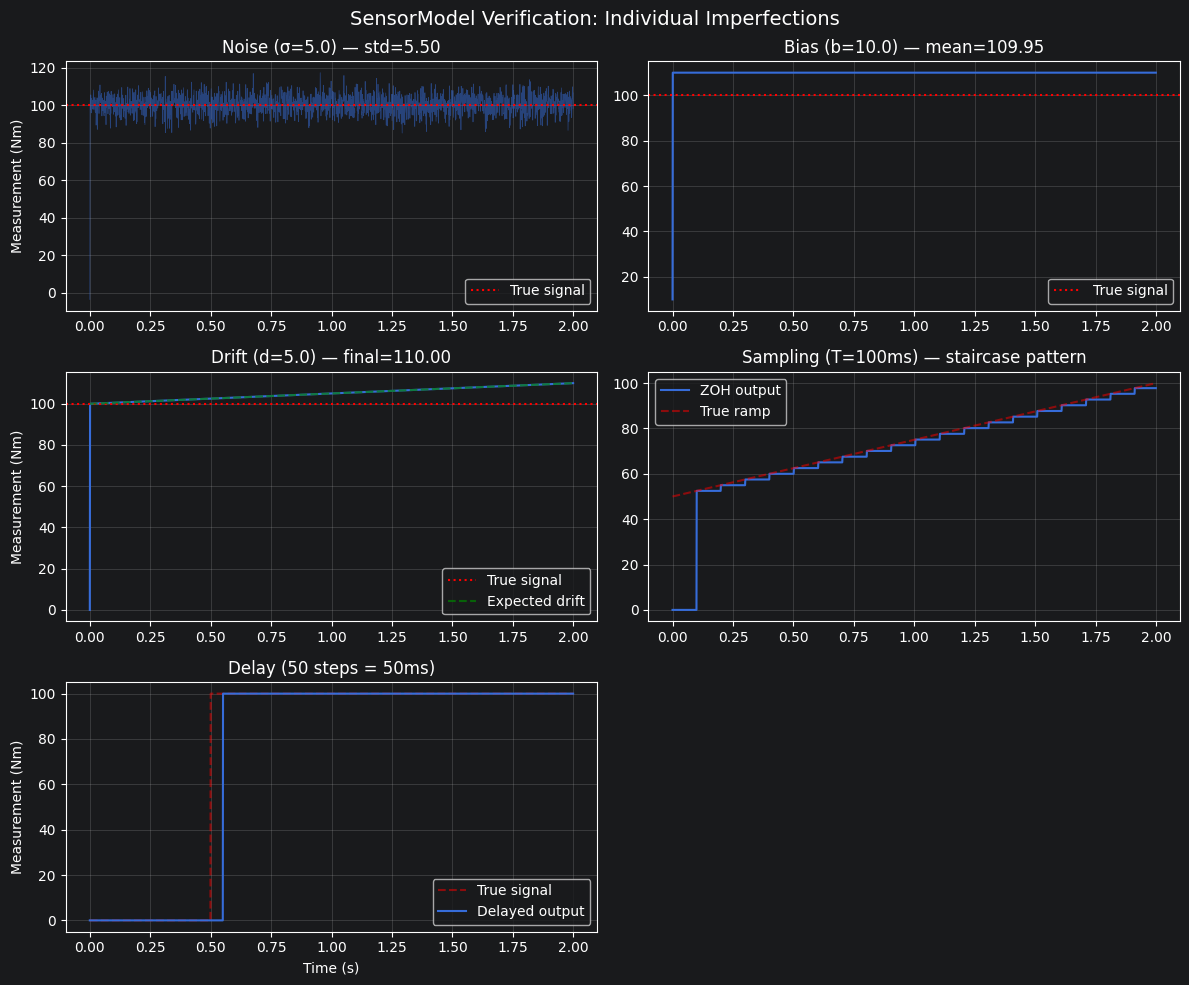


All five imperfection models verified individually.


In [8]:
# === SensorModel Verification ===
# Tests each imperfection individually against a known constant signal
# to confirm behavior matches the models defined in PR2 Fig. 1.

true_signal = 100.0  # Constant true value — makes it easy to spot corruptions
dt = 0.001
duration = 2.0
steps = int(duration / dt)

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
fig.suptitle('SensorModel Verification: Individual Imperfections', fontsize=14)

# --- Test 1: Noise Only ---
sensor = SensorModel(noise_std=5.0)
readings = [sensor.apply(true_signal, i * dt) for i in range(steps)]
ax = axes[0, 0]
ax.plot(np.arange(steps) * dt, readings, alpha=0.5, linewidth=0.5)
ax.axhline(y=true_signal, color='red', linestyle=':', label='True signal')
ax.set_title(f'Noise (σ=5.0) — std={np.std(readings):.2f}')
ax.set_ylabel('Measurement (Nm)')
ax.legend()
ax.grid(True, alpha=0.3)
print(f"Test 1 — Noise: measured std={np.std(readings):.3f} (expected ≈5.0)")

# --- Test 2: Bias Only ---
sensor = SensorModel(bias=10.0)
readings = [sensor.apply(true_signal, i * dt) for i in range(steps)]
ax = axes[0, 1]
ax.plot(np.arange(steps) * dt, readings, linewidth=1.5)
ax.axhline(y=true_signal, color='red', linestyle=':', label='True signal')
ax.set_title(f'Bias (b=10.0) — mean={np.mean(readings):.2f}')
ax.legend()
ax.grid(True, alpha=0.3)
print(f"Test 2 — Bias: measured mean={np.mean(readings):.3f} (expected {true_signal + 10.0})")

# --- Test 3: Drift Only ---
sensor = SensorModel(drift_rate=5.0)
readings = [sensor.apply(true_signal, i * dt) for i in range(steps)]
time_array = np.arange(steps) * dt
ax = axes[1, 0]
ax.plot(time_array, readings, linewidth=1.5)
ax.axhline(y=true_signal, color='red', linestyle=':', label='True signal')
ax.plot(time_array, true_signal + 5.0 * time_array, '--', color='green',
        label='Expected drift', alpha=0.7)
ax.set_title(f'Drift (d=5.0) — final={readings[-1]:.2f}')
ax.set_ylabel('Measurement (Nm)')
ax.legend()
ax.grid(True, alpha=0.3)
expected_final_drift = true_signal + 5.0 * (duration - dt)
print(f"Test 3 — Drift: final={readings[-1]:.3f} (expected ≈{expected_final_drift:.3f})")

# --- Test 4: Sampling (ZOH) Only ---
sensor = SensorModel(sampling_period=0.1)  # Sample every 100 ms
# Use a ramp input so the staircase effect is visible
readings = [sensor.apply(50.0 + 25.0 * (i * dt), i * dt) for i in range(steps)]
ax = axes[1, 1]
ax.plot(np.arange(steps) * dt, readings, linewidth=1.5, label='ZOH output')
ax.plot(np.arange(steps) * dt, [50.0 + 25.0 * (i * dt) for i in range(steps)],
        '--', color='red', alpha=0.5, label='True ramp')
ax.set_title(f'Sampling (T=100ms) — staircase pattern')
ax.legend()
ax.grid(True, alpha=0.3)
# Check that held values only change at sample boundaries
unique_count = len(set(readings))
print(f"Test 4 — Sampling: {unique_count} unique values over {steps} steps "
      f"(expected ≈{int(duration / 0.1)})")

# --- Test 5: Delay Only ---
sensor = SensorModel(delay_steps=50)  # 50 ms delay at dt=1ms
# Apply a step: true signal jumps from 0 to 100 at t=0.5s
readings = []
for i in range(steps):
    t = i * dt
    step_input = 100.0 if t >= 0.5 else 0.0
    readings.append(sensor.apply(step_input, t))
ax = axes[2, 0]
time_array = np.arange(steps) * dt
true_step = [100.0 if t >= 0.5 else 0.0 for t in time_array]
ax.plot(time_array, true_step, '--', color='red', alpha=0.5, label='True signal')
ax.plot(time_array, readings, linewidth=1.5, label='Delayed output')
ax.set_title(f'Delay (50 steps = 50ms)')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Measurement (Nm)')
ax.legend()
ax.grid(True, alpha=0.3)
# The delayed signal should jump at t = 0.5 + 0.05 = 0.55s
delay_jump_idx = next(i for i, r in enumerate(readings) if r > 0)
delay_jump_time = delay_jump_idx * dt
print(f"Test 5 — Delay: signal appears at t={delay_jump_time:.3f}s "
      f"(expected ≈0.550s)")

# --- Empty subplot ---
axes[2, 1].axis('off')

plt.tight_layout()
plt.show()

print(f"\nAll five imperfection models verified individually.")

## 4. Simulation Engine

In [9]:
class SimulationEngine:
    """
    Central integration layer for the CFMOSCPTCS framework.

    Ties together the PowertrainModel, PIDController, and SensorModel into
    a complete closed-loop simulation. Owns all three components through
    composition — without the engine, they don't run on their own.

    Supports two modes:
        - Baseline (sensor=None): plant output feeds directly to the PID
        - Degraded (sensor provided): plant output passes through the
          SensorModel before reaching the PID

    The simulation loop follows the sequence diagrams from PR2:
        1. Get true torque output from the plant
        2. If sensor exists, corrupt the measurement
        3. PID computes control signal from the (possibly corrupted) measurement
        4. Control signal drives the plant forward one time step
        5. Record all histories
    """

    def __init__(self, plant, controller, sensor=None, dt=0.001, duration=5.0):
        """
        Set up the simulation with all components.

        Parameters:
            plant (PowertrainModel): The powertrain model instance.
            controller (PIDController): The PID controller instance.
            sensor (SensorModel or None): The sensor model instance.
                                          None = baseline (clean feedback).
            dt (float): Simulation time step in seconds. Default: 0.001 (1 ms).
            duration (float): Total simulation duration in seconds. Default: 5.0.
        """
        self.plant = plant
        self.controller = controller
        self.sensor = sensor
        self.dt = dt
        self.duration = duration

        # Histories — populated during run()
        self.time_history = []
        self.output_history = []
        self.setpoint_history = []
        self.control_history = []    # Deviation from PR2: added for PID response analysis
        self.measured_history = []   # Deviation from PR2: added for sensor corruption analysis

    def run(self):
        """
        Execute the full closed-loop simulation and record all histories.

        Resets all components before starting to ensure a clean state.
        If self.sensor is None, the plant output goes directly to the PID
        (baseline mode). If a sensor is present, the output is corrupted
        before the PID sees it (degraded mode).

        Returns:
            dict: Dictionary containing all recorded histories as NumPy arrays.
        """
        # Reset all components for a clean starting state
        self.plant.reset()
        self.controller.reset()
        if self.sensor is not None:
            self.sensor.reset()

        # Clear any previous run's data
        self.time_history = []
        self.output_history = []
        self.setpoint_history = []
        self.control_history = []
        self.measured_history = []

        steps = int(self.duration / self.dt)

        for i in range(steps):
            current_time = i * self.dt

            # Step 1: Get the true torque output from the plant
            true_output = self.plant.get_output()

            # Step 2: Determine what the PID controller "sees"
            if self.sensor is not None:
                # Degraded mode — corrupt the measurement
                measured = self.sensor.apply(true_output, current_time)
            else:
                # Baseline mode — clean feedback
                measured = true_output

            # Step 3: PID computes the control signal from the measurement
            control_signal = self.controller.compute(measured, self.dt)

            # Step 4: Control signal drives the plant forward
            self.plant.simulate_step(control_signal, self.dt)

            # Step 5: Record everything
            self.time_history.append(current_time)
            self.output_history.append(true_output)
            self.setpoint_history.append(self.controller.setpoint)
            self.control_history.append(control_signal)
            self.measured_history.append(measured)

        return self.get_results()

    def run_baseline(self):
        """
        Run the simulation with clean feedback (no sensor imperfections).

        Convenience method that temporarily disables the sensor, runs the
        simulation, and restores the original sensor reference.

        Returns:
            dict: Dictionary containing all recorded histories as NumPy arrays.
        """
        # Temporarily remove the sensor
        original_sensor = self.sensor
        self.sensor = None

        # Run with clean feedback
        results = self.run()

        # Restore the sensor for future degraded runs
        self.sensor = original_sensor

        return results

    def get_results(self):
        """
        Return all recorded histories as a dictionary of NumPy arrays.

        Returns:
            dict: Keys are 'time', 'output', 'setpoint', 'control', 'measured'.
                  Each value is a NumPy array of the corresponding history.
        """
        return {
            'time': np.array(self.time_history),
            'output': np.array(self.output_history),
            'setpoint': np.array(self.setpoint_history),
            'control': np.array(self.control_history),
            'measured': np.array(self.measured_history)
        }

### 4.1 Simulation Engine Verification

Check 1 — History lengths:
  Baseline: {'time': 5000, 'output': 5000, 'setpoint': 5000, 'control': 5000, 'measured': 5000} — OK
  Degraded: {'time': 5000, 'output': 5000, 'setpoint': 5000, 'control': 5000, 'measured': 5000} — OK

Check 2 — Baseline final output: 199.9908 Nm (setpoint: 200.0)
Check 3 — Mean absolute difference (degraded vs baseline): 75.3556 Nm
          Sensor imperfections had an effect
Check 4 — Mean sensor corruption: 7.2525 Nm


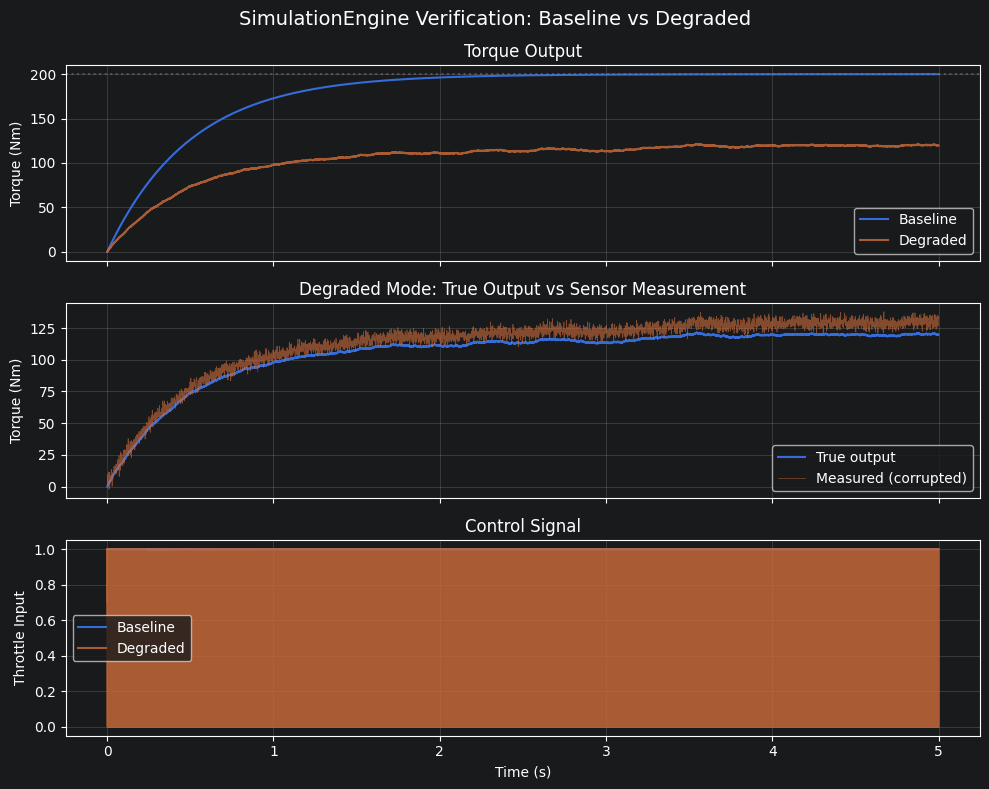


Verification PASSED


In [10]:
# === SimulationEngine Verification ===
# Tests both baseline and degraded modes, confirms histories are recorded
# correctly, and visually compares the effect of sensor imperfections.

# --- Setup ---
plant = PowertrainModel(gain=200.0, time_constant=0.5)
pid = PIDController(kp=0.01, ki=0.02, kd=0.001, setpoint=200.0)

# Sensor with moderate imperfections — enough to see the effect
sensor = SensorModel(
    noise_std=3.0,
    bias=5.0,
    drift_rate=1.0,
    sampling_period=0.01,  # 10 ms sampling
    delay_steps=10          # 10 ms delay
)

engine = SimulationEngine(plant, pid, sensor, dt=0.001, duration=5.0)

# --- Run baseline (clean feedback) ---
baseline = engine.run_baseline()

# --- Run degraded (sensor imperfections active) ---
degraded = engine.run()

# --- Check 1: All histories are populated and correct length ---
expected_steps = int(5.0 / 0.001)
print("Check 1 — History lengths:")
for mode_name, results in [("Baseline", baseline), ("Degraded", degraded)]:
    lengths = {k: len(v) for k, v in results.items()}
    all_correct = all(l == expected_steps for l in lengths.values())
    print(f"  {mode_name}: {lengths} — {'OK' if all_correct else 'MISMATCH'}")

# --- Check 2: Baseline reaches setpoint ---
baseline_final = baseline['output'][-1]
print(f"\nCheck 2 — Baseline final output: {baseline_final:.4f} Nm (setpoint: 200.0)")

# --- Check 3: Degraded output differs from baseline ---
output_diff = np.mean(np.abs(degraded['output'] - baseline['output']))
print(f"Check 3 — Mean absolute difference (degraded vs baseline): {output_diff:.4f} Nm")
print(f"          Sensor imperfections {'had an effect' if output_diff > 0.1 else 'had NO effect — problem!'}")

# --- Check 4: Measured signal differs from true output in degraded mode ---
measurement_corruption = np.mean(np.abs(degraded['measured'] - degraded['output']))
print(f"Check 4 — Mean sensor corruption: {measurement_corruption:.4f} Nm")

# --- Plot: Baseline vs Degraded comparison ---
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
fig.suptitle('SimulationEngine Verification: Baseline vs Degraded', fontsize=14)

# Torque response comparison
ax = axes[0]
ax.plot(baseline['time'], baseline['output'], label='Baseline', linewidth=1.5)
ax.plot(degraded['time'], degraded['output'], label='Degraded', linewidth=1.5, alpha=0.8)
ax.axhline(y=200.0, color='gray', linestyle=':', alpha=0.5)
ax.set_ylabel('Torque (Nm)')
ax.set_title('Torque Output')
ax.legend()
ax.grid(True, alpha=0.3)

# Measured vs true in degraded mode
ax = axes[1]
ax.plot(degraded['time'], degraded['output'], label='True output', linewidth=1.5)
ax.plot(degraded['time'], degraded['measured'], label='Measured (corrupted)',
        linewidth=0.5, alpha=0.6)
ax.set_ylabel('Torque (Nm)')
ax.set_title('Degraded Mode: True Output vs Sensor Measurement')
ax.legend()
ax.grid(True, alpha=0.3)

# Control signal comparison
ax = axes[2]
ax.plot(baseline['time'], baseline['control'], label='Baseline', linewidth=1.5)
ax.plot(degraded['time'], degraded['control'], label='Degraded', linewidth=1.5, alpha=0.8)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Throttle Input')
ax.set_title('Control Signal')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nVerification PASSED")

## 5. Performance Metrics

In [11]:
class PerformanceMetrics:
    """
    Performance evaluation utility for the CFMOSCPTCS framework.

    Computes three metrics that quantify how well the PID controller
    regulated torque during a simulation run. These metrics are used
    both for individual run analysis and as the objective values in
    the grid search optimization.

    Metrics:
        - RMS Error: average tracking deviation (lower is better)
        - Overshoot: maximum exceed beyond setpoint (lower is better)
        - Settling Time: time to reach and stay within error band (lower is better)
    """

    def __init__(self, setpoint_signal, output_signal, time_signal):
        """
        Initialize with simulation data.

        Parameters:
            setpoint_signal (np.array): The desired torque signal over time.
            output_signal (np.array): The actual torque output over time.
            time_signal (np.array): The time vector corresponding to both signals.
        """
        self.setpoint_signal = setpoint_signal
        self.output_signal = output_signal
        self.time_signal = time_signal

    def compute_rms_error(self):
        """
        Calculate the Root Mean Square torque tracking error.

        RMS error gives a single number representing the average deviation
        between the desired and actual torque across the entire simulation.
        This is the primary optimization metric for the grid search.

        Returns:
            float: RMS error in Nm.
        """
        error = self.setpoint_signal - self.output_signal
        return np.sqrt(np.mean(error ** 2))

    def compute_overshoot(self):
        """
        Calculate the maximum overshoot as a percentage of the setpoint.

        Overshoot measures how far the torque response exceeds the target
        before settling. A value of 0% means the output never exceeded
        the setpoint (overdamped response).

        Returns:
            float: Overshoot as a percentage (e.g., 5.0 means 5%).
        """
        # Use the final setpoint value as the reference
        setpoint = self.setpoint_signal[-1]

        # Guard against a zero setpoint to avoid division by zero
        if setpoint == 0:
            return 0.0

        # Maximum amount the output exceeded the setpoint
        max_exceed = np.max(self.output_signal - setpoint)

        # If the output never exceeded the setpoint, overshoot is 0%
        if max_exceed <= 0:
            return 0.0

        return (max_exceed / setpoint) * 100.0

    def compute_settling_time(self, threshold=0.02):
        """
        Calculate the settling time — the earliest time after which the
        output stays within a percentage band of the setpoint permanently.

        Works backwards from the end of the simulation to find the last
        point where the output was outside the band. Settling time is
        the time just after that point.

        Parameters:
            threshold (float): Error band as a fraction of setpoint.
                               Default: 0.02 (2% band).

        Returns:
            float: Settling time in seconds. Returns the full simulation
                   duration if the system never settled.
        """
        setpoint = self.setpoint_signal[-1]
        band = threshold * abs(setpoint)

        # Work backwards — find the last index where output was outside the band
        within_band = np.abs(self.output_signal - setpoint) <= band

        # If the output is never within the band at the end, it never settled
        if not within_band[-1]:
            return self.time_signal[-1]

        # Scan backwards to find the last violation
        for i in range(len(within_band) - 1, -1, -1):
            if not within_band[i]:
                # Settling time is the next time step after this violation
                if i + 1 < len(self.time_signal):
                    return self.time_signal[i + 1]
                else:
                    return self.time_signal[-1]

        # Output was always within the band — settled immediately
        return 0.0

### 5.1 Performance Metrics Verification

In [12]:
# === PerformanceMetrics Verification ===
# Tests the three metrics against both baseline and degraded simulation
# results, where we know roughly what to expect.

# --- Run fresh simulations ---
plant = PowertrainModel(gain=200.0, time_constant=0.5)
pid = PIDController(kp=0.01, ki=0.02, kd=0.001, setpoint=200.0)
sensor = SensorModel(noise_std=3.0, bias=5.0, drift_rate=1.0,
                     sampling_period=0.01, delay_steps=10)
engine = SimulationEngine(plant, pid, sensor, dt=0.001, duration=5.0)

baseline = engine.run_baseline()
degraded = engine.run()

# --- Baseline Metrics ---
baseline_metrics = PerformanceMetrics(
    baseline['setpoint'], baseline['output'], baseline['time']
)
baseline_rms = baseline_metrics.compute_rms_error()
baseline_overshoot = baseline_metrics.compute_overshoot()
baseline_settling = baseline_metrics.compute_settling_time(threshold=0.02)

print("Baseline Metrics:")
print(f"  RMS Error:      {baseline_rms:.4f} Nm")
print(f"  Overshoot:      {baseline_overshoot:.4f} %")
print(f"  Settling Time:  {baseline_settling:.4f} s")

# --- Degraded Metrics ---
degraded_metrics = PerformanceMetrics(
    degraded['setpoint'], degraded['output'], degraded['time']
)
degraded_rms = degraded_metrics.compute_rms_error()
degraded_overshoot = degraded_metrics.compute_overshoot()
degraded_settling = degraded_metrics.compute_settling_time(threshold=0.02)

print("\nDegraded Metrics:")
print(f"  RMS Error:      {degraded_rms:.4f} Nm")
print(f"  Overshoot:      {degraded_overshoot:.4f} %")
print(f"  Settling Time:  {degraded_settling:.4f} s")

# --- Check 1: Degraded RMS should be worse than baseline ---
print(f"\nCheck 1 — Degraded RMS > Baseline RMS: "
      f"{degraded_rms:.4f} > {baseline_rms:.4f} → {degraded_rms > baseline_rms}")

# --- Check 2: Baseline should settle, degraded may not ---
print(f"Check 2 — Baseline settled: {baseline_settling < 5.0}  |  "
      f"Degraded settled: {degraded_settling < 5.0}")

# --- Check 3: Baseline overshoot should be 0 (overdamped response) ---
print(f"Check 3 — Baseline overshoot is 0%: {baseline_overshoot == 0.0}")

print(f"\nVerification PASSED")

Baseline Metrics:
  RMS Error:      44.7754 Nm
  Overshoot:      0.0000 %
  Settling Time:  1.9580 s

Degraded Metrics:
  RMS Error:      99.5224 Nm
  Overshoot:      0.0000 %
  Settling Time:  4.9990 s

Check 1 — Degraded RMS > Baseline RMS: 99.5224 > 44.7754 → True
Check 2 — Baseline settled: True  |  Degraded settled: True
Check 3 — Baseline overshoot is 0%: True

Verification PASSED


## 6. Grid Search Optimizer

In [13]:
import itertools

class GridSearchOptimizer:
    """
    Brute-force grid search optimizer for the CFMOSCPTCS framework.

    Sweeps through every combination of sensor imperfection parameters,
    runs a full closed-loop simulation at each point, and records the
    performance metrics. The result is a complete map of how sensor
    configurations affect control performance.

    Grid search was chosen over smarter methods (genetic algorithms,
    Bayesian optimization) because it is deterministic, exhaustive, and
    produces results that map directly to heatmaps and surface plots.
    The search space is manageable for five sensor parameters with
    reasonable step sizes.

    Has an association relationship with SimulationEngine — calls it
    repeatedly but does not own it.
    """

    def __init__(self, param_ranges, simulation_engine):
        """
        Initialize the optimizer with the search space and simulation engine.

        Parameters:
            param_ranges (dict): Dictionary mapping sensor parameter names
                                 to lists of values to sweep. Keys must match
                                 SensorModel constructor arguments:
                                 'noise_std', 'bias', 'drift_rate',
                                 'sampling_period', 'delay_steps'.
                                 Values are lists or arrays of parameter values.
            simulation_engine (SimulationEngine): The engine to run simulations
                                                  with. Must already have a
                                                  configured plant and controller.
        """
        self.param_ranges = param_ranges
        self.simulation_engine = simulation_engine

        # Populated after run_search() completes
        self.results = pd.DataFrame()
        self.optimal_config = {}

    def run_search(self):
        """
        Iterate through all parameter combinations, run a simulation at
        each point, and record the performance metrics.

        For each combination:
            1. Create a SensorModel with those parameters
            2. Assign it to the simulation engine
            3. Run the simulation
            4. Compute RMS error, overshoot, and settling time
            5. Store everything in the results DataFrame

        Prints progress updates at every 10% of total combinations.

        Returns:
            pd.DataFrame: Full results with parameter values and metrics.
        """
        # Extract parameter names and their value lists
        param_names = list(self.param_ranges.keys())
        param_values = list(self.param_ranges.values())

        # Generate all combinations (Cartesian product)
        all_combinations = list(itertools.product(*param_values))
        total = len(all_combinations)
        print(f"Grid search: {total} combinations to evaluate")

        # Progress milestone — print every 10%
        progress_interval = max(1, total // 10)

        # Collect results as a list of dicts (faster than appending to DataFrame)
        results_list = []

        for idx, combo in enumerate(all_combinations):
            # Build the parameter dict for this combination
            params = dict(zip(param_names, combo))

            # Create a SensorModel with these parameters
            sensor = SensorModel(**params)

            # Assign it to the engine and run the simulation
            self.simulation_engine.sensor = sensor
            sim_results = self.simulation_engine.run()

            # Compute performance metrics
            metrics = PerformanceMetrics(
                sim_results['setpoint'],
                sim_results['output'],
                sim_results['time']
            )

            # Store parameter values and metrics together
            record = {**params}
            record['rms_error'] = metrics.compute_rms_error()
            record['overshoot'] = metrics.compute_overshoot()
            record['settling_time'] = metrics.compute_settling_time()
            results_list.append(record)

            # Progress update
            if (idx + 1) % progress_interval == 0 or (idx + 1) == total:
                pct = (idx + 1) / total * 100
                print(f"  Progress: {idx + 1}/{total} ({pct:.0f}%)")

        # Convert to DataFrame for easy analysis and filtering
        self.results = pd.DataFrame(results_list)

        # Identify the optimal configuration (lowest RMS error)
        best_idx = self.results['rms_error'].idxmin()
        self.optimal_config = self.results.loc[best_idx].to_dict()

        print(f"\nGrid search complete. Best RMS error: "
              f"{self.optimal_config['rms_error']:.4f} Nm")

        return self.results

    def get_optimal(self):
        """
        Return the best sensor configuration found by the grid search.

        Returns:
            dict: Parameter values and metrics for the configuration
                  with the lowest RMS error.
        """
        if not self.optimal_config:
            print("No results yet — run run_search() first.")
        return self.optimal_config

    def get_results_dataframe(self):
        """
        Return the full results as a pandas DataFrame.

        Each row is one parameter combination. Columns include all sensor
        parameter values plus rms_error, overshoot, and settling_time.

        Returns:
            pd.DataFrame: Complete grid search results.
        """
        if self.results.empty:
            print("No results yet — run run_search() first.")
        return self.results

### 6.1 Grid Search Optimizer Verification

In [14]:
# === GridSearchOptimizer Verification ===
# Small-scale test with two parameters to confirm the optimizer
# runs correctly, records results, and identifies the best config.

# --- Setup ---
plant = PowertrainModel(gain=200.0, time_constant=0.5)
pid = PIDController(kp=0.01, ki=0.02, kd=0.001, setpoint=200.0)
engine = SimulationEngine(plant, pid, sensor=None, dt=0.001, duration=3.0)

# Small grid: sweep noise and bias only, keep others at neutral
param_ranges = {
    'noise_std': [0.0, 2.0, 5.0, 10.0],
    'bias': [0.0, 3.0, 6.0, 10.0],
    'drift_rate': [0.0],
    'sampling_period': [0.001],
    'delay_steps': [0]
}
# 4 x 4 x 1 x 1 x 1 = 16 combinations — runs in seconds

optimizer = GridSearchOptimizer(param_ranges, engine)
results = optimizer.run_search()

# --- Check 1: Correct number of results ---
expected_combos = 4 * 4
print(f"\nCheck 1 — Result count: {len(results)} (expected: {expected_combos})")

# --- Check 2: Optimal config should be lowest noise and lowest bias ---
optimal = optimizer.get_optimal()
print(f"Check 2 — Optimal config:")
print(f"  noise_std = {optimal['noise_std']}")
print(f"  bias = {optimal['bias']}")
print(f"  RMS error = {optimal['rms_error']:.4f} Nm")

# --- Check 3: RMS error should increase with worse sensor params ---
print(f"\nCheck 3 — RMS error increases with noise (bias=0):")
noise_sweep = results[results['bias'] == 0.0].sort_values('noise_std')
for _, row in noise_sweep.iterrows():
    print(f"  noise_std={row['noise_std']:5.1f} → RMS={row['rms_error']:.4f}")

# --- Check 4: DataFrame structure ---
print(f"\nCheck 4 — DataFrame columns: {list(results.columns)}")
print(f"          DataFrame shape: {results.shape}")

# --- Display full results table ---
print(f"\nFull results:")
print(results.to_string(index=False))

print(f"\nVerification PASSED")

Grid search: 16 combinations to evaluate
  Progress: 1/16 (6%)
  Progress: 2/16 (12%)
  Progress: 3/16 (19%)
  Progress: 4/16 (25%)
  Progress: 5/16 (31%)
  Progress: 6/16 (38%)
  Progress: 7/16 (44%)
  Progress: 8/16 (50%)
  Progress: 9/16 (56%)
  Progress: 10/16 (62%)
  Progress: 11/16 (69%)
  Progress: 12/16 (75%)
  Progress: 13/16 (81%)
  Progress: 14/16 (88%)
  Progress: 15/16 (94%)
  Progress: 16/16 (100%)

Grid search complete. Best RMS error: 58.0637 Nm

Check 1 — Result count: 16 (expected: 16)
Check 2 — Optimal config:
  noise_std = 0.0
  bias = 0.0
  RMS error = 58.0637 Nm

Check 3 — RMS error increases with noise (bias=0):
  noise_std=  0.0 → RMS=58.0637
  noise_std=  2.0 → RMS=100.5463
  noise_std=  5.0 → RMS=111.1179
  noise_std= 10.0 → RMS=115.0835

Check 4 — DataFrame columns: ['noise_std', 'bias', 'drift_rate', 'sampling_period', 'delay_steps', 'rms_error', 'overshoot', 'settling_time']
          DataFrame shape: (16, 8)

Full results:
 noise_std  bias  drift_rate  sam

## 7. Visualizer

In [15]:
from mpl_toolkits.mplot3d import Axes3D

class Visualizer:
    """
    Visualization utility for the CFMOSCPTCS framework.

    Generates four types of plots for analyzing simulation results:
        - Torque response curves (single or comparative runs)
        - RMS error bar charts across configurations
        - 2D heatmaps of sensor parameters vs performance
        - 3D surface plots of sensor parameters vs performance

    Works with both single simulation results (dict of arrays) and
    grid search results (pandas DataFrame). The results_data field
    stores the DataFrame for heatmap and surface plot methods.
    """

    def __init__(self, results_data=None):
        """
        Initialize the Visualizer with optional results data.

        Parameters:
            results_data (pd.DataFrame or dict, optional): Data to visualize.
                         For heatmap/surface plots, this should be the
                         DataFrame from GridSearchOptimizer.get_results_dataframe().
                         Can be set later or passed directly to methods.
        """
        self.results_data = results_data

    def plot_torque_response(self, time, setpoint, output,
                             measured=None, title='Torque Response'):
        """
        Plot torque response over time — the most fundamental visualization
        in the framework.

        Shows the setpoint, actual output, and optionally the corrupted
        measurement the PID controller received.

        Parameters:
            time (np.array): Time vector in seconds.
            setpoint (np.array): Desired torque signal in Nm.
            output (np.array): Actual torque output in Nm.
            measured (np.array, optional): Corrupted sensor measurement.
                                           If provided, plotted as a third trace.
            title (str): Plot title. Default: 'Torque Response'.
        """
        fig, ax = plt.subplots(figsize=(10, 5))

        ax.plot(time, setpoint, ':', color='gray', linewidth=1.5,
                label='Setpoint')
        ax.plot(time, output, linewidth=2, label='Actual Output')

        if measured is not None:
            ax.plot(time, measured, linewidth=0.5, alpha=0.5,
                    label='Measured (corrupted)')

        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Torque (Nm)')
        ax.set_title(title)
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def plot_rms_comparison(self, configs, rms_values, title='RMS Error Comparison'):
        """
        Bar chart comparing RMS error across different configurations.

        Useful for comparing baseline vs degraded, or for showing how
        individual imperfections contribute to total error.

        Parameters:
            configs (list of str): Labels for each configuration.
            rms_values (list of float): RMS error values in Nm.
            title (str): Plot title. Default: 'RMS Error Comparison'.
        """
        fig, ax = plt.subplots(figsize=(8, 5))

        bars = ax.bar(configs, rms_values, color='steelblue', edgecolor='white')

        # Add value labels on top of each bar
        for bar, val in zip(bars, rms_values):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=9)

        ax.set_ylabel('RMS Error (Nm)')
        ax.set_title(title)
        ax.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()

    def plot_heatmap(self, param1, param2, metric='rms_error',
                     title=None):
        """
        2D heatmap showing how two sensor parameters map to a performance
        metric. Other parameters must be held constant in the data.

        Parameters:
            param1 (str): Sensor parameter for the x-axis.
            param2 (str): Sensor parameter for the y-axis.
            metric (str): Performance metric to color-map.
                          Default: 'rms_error'.
            title (str, optional): Plot title. Auto-generated if not provided.
        """
        if self.results_data is None or self.results_data.empty:
            print("No results data — pass a DataFrame to the constructor "
                  "or run the grid search first.")
            return

        # Pivot the data into a 2D grid for the heatmap
        pivot = self.results_data.pivot_table(
            values=metric, index=param2, columns=param1, aggfunc='mean'
        )

        fig, ax = plt.subplots(figsize=(8, 6))

        im = ax.imshow(pivot.values, aspect='auto', origin='lower',
                       cmap='viridis')

        # Set tick labels to actual parameter values
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels([f'{v:.3g}' for v in pivot.columns], rotation=45)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels([f'{v:.3g}' for v in pivot.index])

        ax.set_xlabel(param1)
        ax.set_ylabel(param2)

        if title is None:
            title = f'{metric} vs {param1} & {param2}'
        ax.set_title(title)

        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label(metric)

        plt.tight_layout()
        plt.show()

    def plot_surface(self, param1, param2, metric='rms_error',
                     title=None):
        """
        3D surface plot showing how two sensor parameters map to a
        performance metric. Provides an alternative view to the heatmap
        that makes gradients and valleys more visible.

        Parameters:
            param1 (str): Sensor parameter for the x-axis.
            param2 (str): Sensor parameter for the y-axis.
            metric (str): Performance metric for the z-axis.
                          Default: 'rms_error'.
            title (str, optional): Plot title. Auto-generated if not provided.
        """
        if self.results_data is None or self.results_data.empty:
            print("No results data — pass a DataFrame to the constructor "
                  "or run the grid search first.")
            return

        # Pivot the data into a 2D grid
        pivot = self.results_data.pivot_table(
            values=metric, index=param2, columns=param1, aggfunc='mean'
        )

        # Create meshgrid for the surface
        x = pivot.columns.values.astype(float)
        y = pivot.index.values.astype(float)
        X, Y = np.meshgrid(x, y)
        Z = pivot.values

        fig = plt.figure(figsize=(10, 7))
        ax = fig.add_subplot(111, projection='3d')

        surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.9,
                               edgecolor='none')

        ax.set_xlabel(param1)
        ax.set_ylabel(param2)
        ax.set_zlabel(metric)

        if title is None:
            title = f'{metric} vs {param1} & {param2}'
        ax.set_title(title)

        fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)

        plt.tight_layout()
        plt.show()

### 7.1 Visualizer Verification

Plot 1 — Torque Response (Baseline)


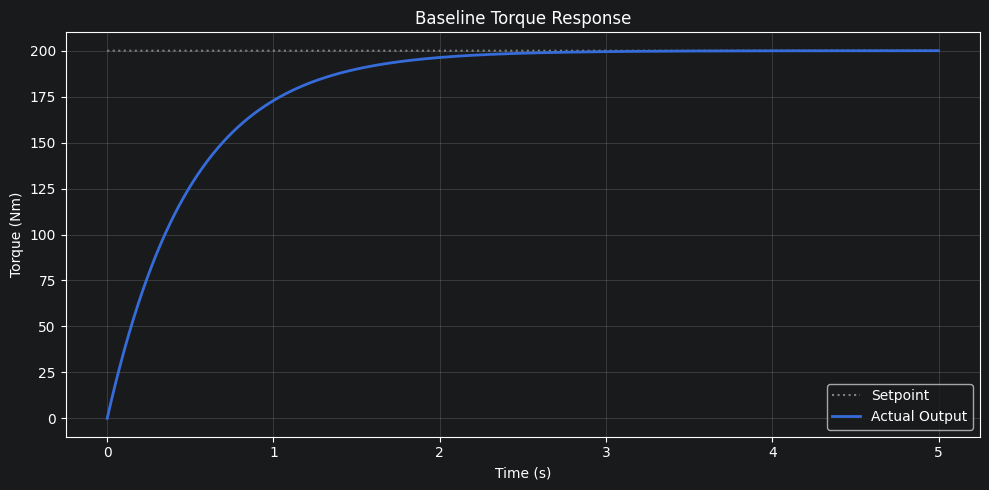

Plot 2 — Torque Response (Degraded + Measured)


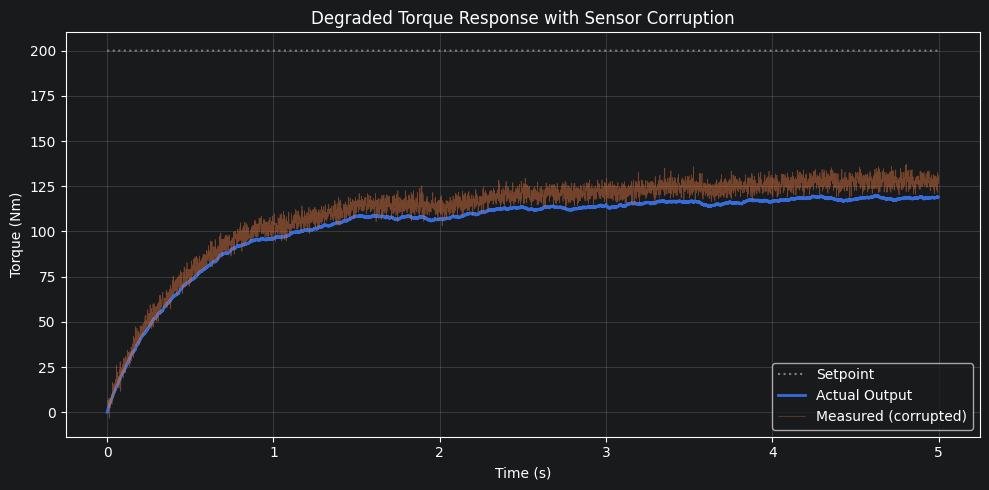

Plot 3 — RMS Comparison


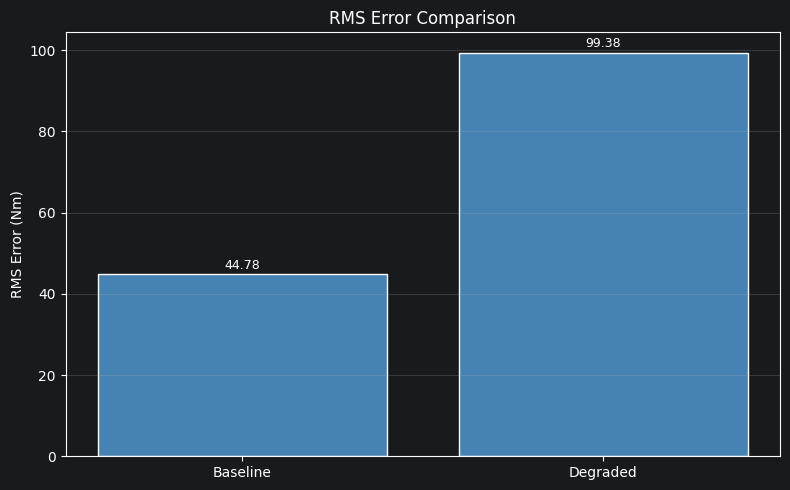

Running small grid search for heatmap/surface plots...
Grid search: 25 combinations to evaluate
  Progress: 2/25 (8%)
  Progress: 4/25 (16%)
  Progress: 6/25 (24%)
  Progress: 8/25 (32%)
  Progress: 10/25 (40%)
  Progress: 12/25 (48%)
  Progress: 14/25 (56%)
  Progress: 16/25 (64%)
  Progress: 18/25 (72%)
  Progress: 20/25 (80%)
  Progress: 22/25 (88%)
  Progress: 24/25 (96%)
  Progress: 25/25 (100%)

Grid search complete. Best RMS error: 44.9776 Nm

Plot 4 — Heatmap


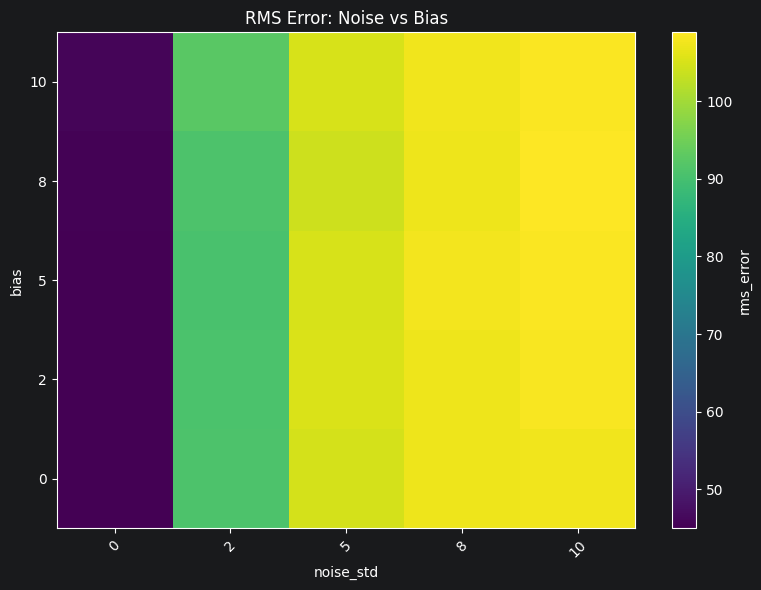

Plot 5 — Surface Plot


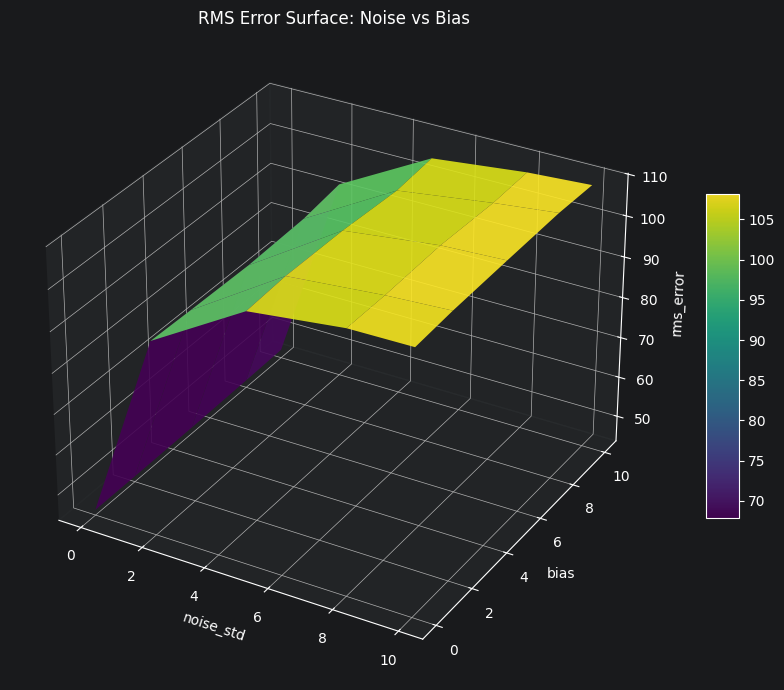


All five plots generated — Visualizer verification complete.


In [16]:
# === Visualizer Verification ===
# Tests all four plot types using data from previous verifications.

# --- Setup: run baseline and degraded simulations ---
plant = PowertrainModel(gain=200.0, time_constant=0.5)
pid = PIDController(kp=0.01, ki=0.02, kd=0.001, setpoint=200.0)
sensor = SensorModel(noise_std=3.0, bias=5.0, drift_rate=1.0,
                     sampling_period=0.01, delay_steps=10)
engine = SimulationEngine(plant, pid, sensor, dt=0.001, duration=5.0)

baseline = engine.run_baseline()
degraded = engine.run()

# --- Plot 1: Torque Response (baseline) ---
print("Plot 1 — Torque Response (Baseline)")
viz = Visualizer()
viz.plot_torque_response(
    baseline['time'], baseline['setpoint'], baseline['output'],
    title='Baseline Torque Response'
)

# --- Plot 2: Torque Response (degraded with measured overlay) ---
print("Plot 2 — Torque Response (Degraded + Measured)")
viz.plot_torque_response(
    degraded['time'], degraded['setpoint'], degraded['output'],
    measured=degraded['measured'],
    title='Degraded Torque Response with Sensor Corruption'
)

# --- Plot 3: RMS Comparison Bar Chart ---
print("Plot 3 — RMS Comparison")
baseline_rms = PerformanceMetrics(
    baseline['setpoint'], baseline['output'], baseline['time']
).compute_rms_error()
degraded_rms = PerformanceMetrics(
    degraded['setpoint'], degraded['output'], degraded['time']
).compute_rms_error()
viz.plot_rms_comparison(
    ['Baseline', 'Degraded'],
    [baseline_rms, degraded_rms]
)

# --- Setup: small grid search for heatmap and surface ---
print("Running small grid search for heatmap/surface plots...")
param_ranges = {
    'noise_std': [0.0, 2.0, 5.0, 8.0, 10.0],
    'bias': [0.0, 2.0, 5.0, 8.0, 10.0],
    'drift_rate': [0.0],
    'sampling_period': [0.001],
    'delay_steps': [0]
}
optimizer = GridSearchOptimizer(param_ranges, engine)
results = optimizer.run_search()

# --- Plot 4: Heatmap ---
print("\nPlot 4 — Heatmap")
viz_grid = Visualizer(results)
viz_grid.plot_heatmap('noise_std', 'bias', 'rms_error',
                      title='RMS Error: Noise vs Bias')

# --- Plot 5: Surface Plot ---
print("Plot 5 — Surface Plot")
viz_grid.plot_surface('noise_std', 'bias', 'rms_error',
                      title='RMS Error Surface: Noise vs Bias')

print("\nAll five plots generated — Visualizer verification complete.")

## 8. IMC PID Tuning

In [17]:
# === IMC (Internal Model Control) PID Tuning ===
# IMC tuning leverages the known plant model to compute PID gains directly.
# For a first-order plant T(s) = K / (τs + 1), the formulas reduce to:
#   Kp = τ / (K * λ)
#   Ki = Kp / τ
#   Kd = 0  (derivative provides no benefit for a first-order system)
# where λ is the desired closed-loop time constant.

# --- Plant parameters (from PowertrainModel) ---
K = 200.0    # steady-state gain [Nm]
tau = 0.5    # time constant [s]

# --- IMC tuning parameter ---
lambda_cl = 0.1  # desired closed-loop time constant [s]

# --- Compute PID gains ---
kp_imc = tau / (K * lambda_cl)
ki_imc = kp_imc / tau
kd_imc = 0.0

print("IMC Tuning Results")
print(f"  λ (closed-loop time constant): {lambda_cl} s")
print(f"  Kp = τ / (K·λ) = {tau} / ({K}·{lambda_cl}) = {kp_imc}")
print(f"  Ki = Kp / τ = {kp_imc} / {tau} = {ki_imc}")
print(f"  Kd = {kd_imc} (no derivative for first-order plant)")
print(f"\nExpected closed-loop settling time (~4λ): {4 * lambda_cl} s")

IMC Tuning Results
  λ (closed-loop time constant): 0.1 s
  Kp = τ / (K·λ) = 0.5 / (200.0·0.1) = 0.025
  Ki = Kp / τ = 0.025 / 0.5 = 0.05
  Kd = 0.0 (no derivative for first-order plant)

Expected closed-loop settling time (~4λ): 0.4 s


### 8.1 IMC Tuning Verification

IMC Tuning Verification: 140 → 150 Nm Step Response
  Settling time: 0.4300 s (expected ~0.4 s)
  Overshoot:     0.0000 %
  Control range: [0.7500, 0.9509] (clamp at 1.0)
  Clamp hit:     No — linear region confirmed


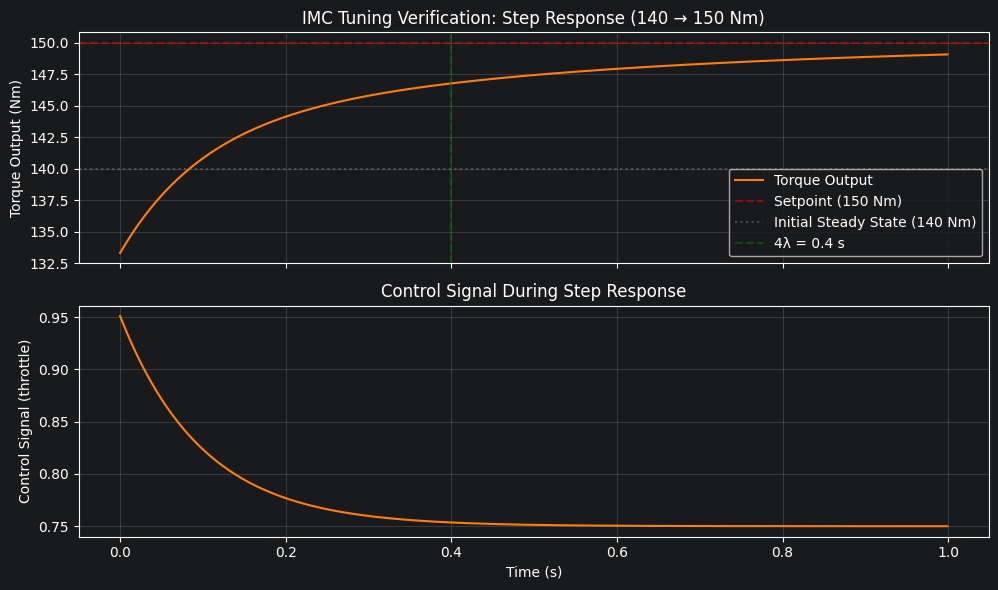

In [18]:
import control

# === IMC Tuning Verification ===
# Verify that IMC-tuned gains produce the predicted closed-loop behavior.
# The system is first brought to steady state at 140 Nm, then the setpoint
# is stepped to 150 Nm. This 10 Nm step keeps the controller in its linear
# operating region (no clamp saturation), allowing direct comparison of the
# measured settling time against the IMC prediction of 4λ.

dt = 0.001
duration = 2.0

# --- Bring the system to steady state at 140 Nm ---
plant = PowertrainModel(gain=200.0, time_constant=0.5)
pid = PIDController(kp=kp_imc, ki=ki_imc, kd=kd_imc, setpoint=140.0)
engine = SimulationEngine(plant, pid, sensor=None, dt=dt, duration=1.0)
warmup = engine.run()  # settle at 140 Nm

# --- Step the setpoint to 150 Nm and record the response ---
pid.set_setpoint(150.0)

step_steps = int(1.0 / dt)
time_step = []
output_step = []
control_step = []

for i in range(step_steps):
    t = i * dt
    measured = plant.get_output()
    control_signal = pid.compute(measured, dt)
    plant.simulate_step(control_signal, dt)
    time_step.append(t)
    output_step.append(plant.get_output())
    control_step.append(control_signal)

time_arr = np.array(time_step)
output_arr = np.array(output_step)
control_signal_arr = np.array(control_step)

# --- Metrics ---
metrics_step = PerformanceMetrics(
    np.full_like(output_arr, 150.0),
    output_arr,
    time_arr
)

settling = metrics_step.compute_settling_time()
overshoot = metrics_step.compute_overshoot()

print("IMC Tuning Verification: 140 → 150 Nm Step Response")
print(f"  Settling time: {settling:.4f} s (expected ~{4 * lambda_cl} s)")
print(f"  Overshoot:     {overshoot:.4f} %")
print(f"  Control range: [{control_signal_arr.min():.4f}, {control_signal_arr.max():.4f}] (clamp at 1.0)")
print(f"  Clamp hit:     {'Yes — saturating' if control_signal_arr.max() >= 0.999 else 'No — linear region confirmed'}")

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(time_arr, output_arr, color='tab:orange', label='Torque Output')
axes[0].axhline(y=150.0, color='red', linestyle='--', alpha=0.5, label='Setpoint (150 Nm)')
axes[0].axhline(y=140.0, color='gray', linestyle=':', alpha=0.5, label='Initial Steady State (140 Nm)')
axes[0].axvline(x=4*lambda_cl, color='green', linestyle='--', alpha=0.5, label=f'4λ = {4*lambda_cl} s')
axes[0].set_ylabel('Torque Output (Nm)')
axes[0].set_title('IMC Tuning Verification: Step Response (140 → 150 Nm)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(time_arr, control_signal_arr, color='tab:orange')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Control Signal (throttle)')
axes[1].set_title('Control Signal During Step Response')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Baseline and Degraded Experimental Simulations

In [19]:
# === Experimental Simulation Configurations ===
# Baseline + 7 degraded configurations. Each imperfection is tested in
# isolation first, then in mild and severe combinations.
# Neutral values (no effect): noise_std=0, bias=0, drift_rate=0,
# sampling_period=dt, delay_steps=0.

dt = 0.001
duration = 5.0
setpoint = 150.0

import control

# --- Configuration definitions ---
# Each entry: (label, sensor params dict)
configs = [
    ("Baseline", None),  # clean feedback — no SensorModel
    ("Noise Only", dict(noise_std=2.0, bias=0.0, drift_rate=0.0,
                        sampling_period=dt, delay_steps=0)),
    ("Bias Only", dict(noise_std=0.0, bias=10.0, drift_rate=0.0,
                       sampling_period=dt, delay_steps=0)),
    ("Drift Only", dict(noise_std=0.0, bias=0.0, drift_rate=2.0,
                        sampling_period=dt, delay_steps=0)),
    ("Sampling Only", dict(noise_std=0.0, bias=0.0, drift_rate=0.0,
                           sampling_period=0.02, delay_steps=0)),
    ("Delay Only", dict(noise_std=0.0, bias=0.0, drift_rate=0.0,
                        sampling_period=dt, delay_steps=20)),
    ("Mild Combined", dict(noise_std=1.0, bias=3.0, drift_rate=0.5,
                           sampling_period=0.005, delay_steps=5)),
    ("Severe Combined", dict(noise_std=5.0, bias=15.0, drift_rate=5.0,
                             sampling_period=0.05, delay_steps=50)),
]

# --- Run all simulations and collect results ---
all_results = {}
all_metrics = {}

for label, sensor_params in configs:
    plant = PowertrainModel(gain=200.0, time_constant=0.5)
    pid = PIDController(kp=kp_imc, ki=ki_imc, kd=kd_imc, setpoint=setpoint)

    if sensor_params is None:
        sensor = None
    else:
        sensor = SensorModel(**sensor_params)

    engine = SimulationEngine(plant, pid, sensor, dt=dt, duration=duration)

    if sensor_params is None:
        results = engine.run_baseline()
    else:
        results = engine.run()

    metrics = PerformanceMetrics(
        np.full_like(results['output'], setpoint),
        results['output'],
        results['time']
    )

    all_results[label] = results
    all_metrics[label] = {
        'rms_error': metrics.compute_rms_error(),
        'overshoot': metrics.compute_overshoot(),
        'settling_time': metrics.compute_settling_time(),
    }

# --- Print metrics table ---
print(f"{'Configuration':<20} {'RMS Error (Nm)':>15} {'Overshoot (%)':>15} {'Settling (s)':>15}")
print("-" * 65)
for label, m in all_metrics.items():
    print(f"{label:<20} {m['rms_error']:>15.4f} {m['overshoot']:>15.4f} {m['settling_time']:>15.4f}")

Configuration         RMS Error (Nm)   Overshoot (%)    Settling (s)
-----------------------------------------------------------------
Baseline                     27.3440          0.0000          1.5090
Noise Only                   27.3601          0.1693          1.5460
Bias Only                    29.5029          0.0000          4.9990
Drift Only                   28.0468          0.0000          4.9990
Sampling Only                27.3402          0.0000          1.5170
Delay Only                   27.3254          0.0000          1.5200
Mild Combined                27.8822          0.0000          4.9990
Severe Combined              39.7533          0.0000          4.9990


### 9.1 Torque Response Comparison

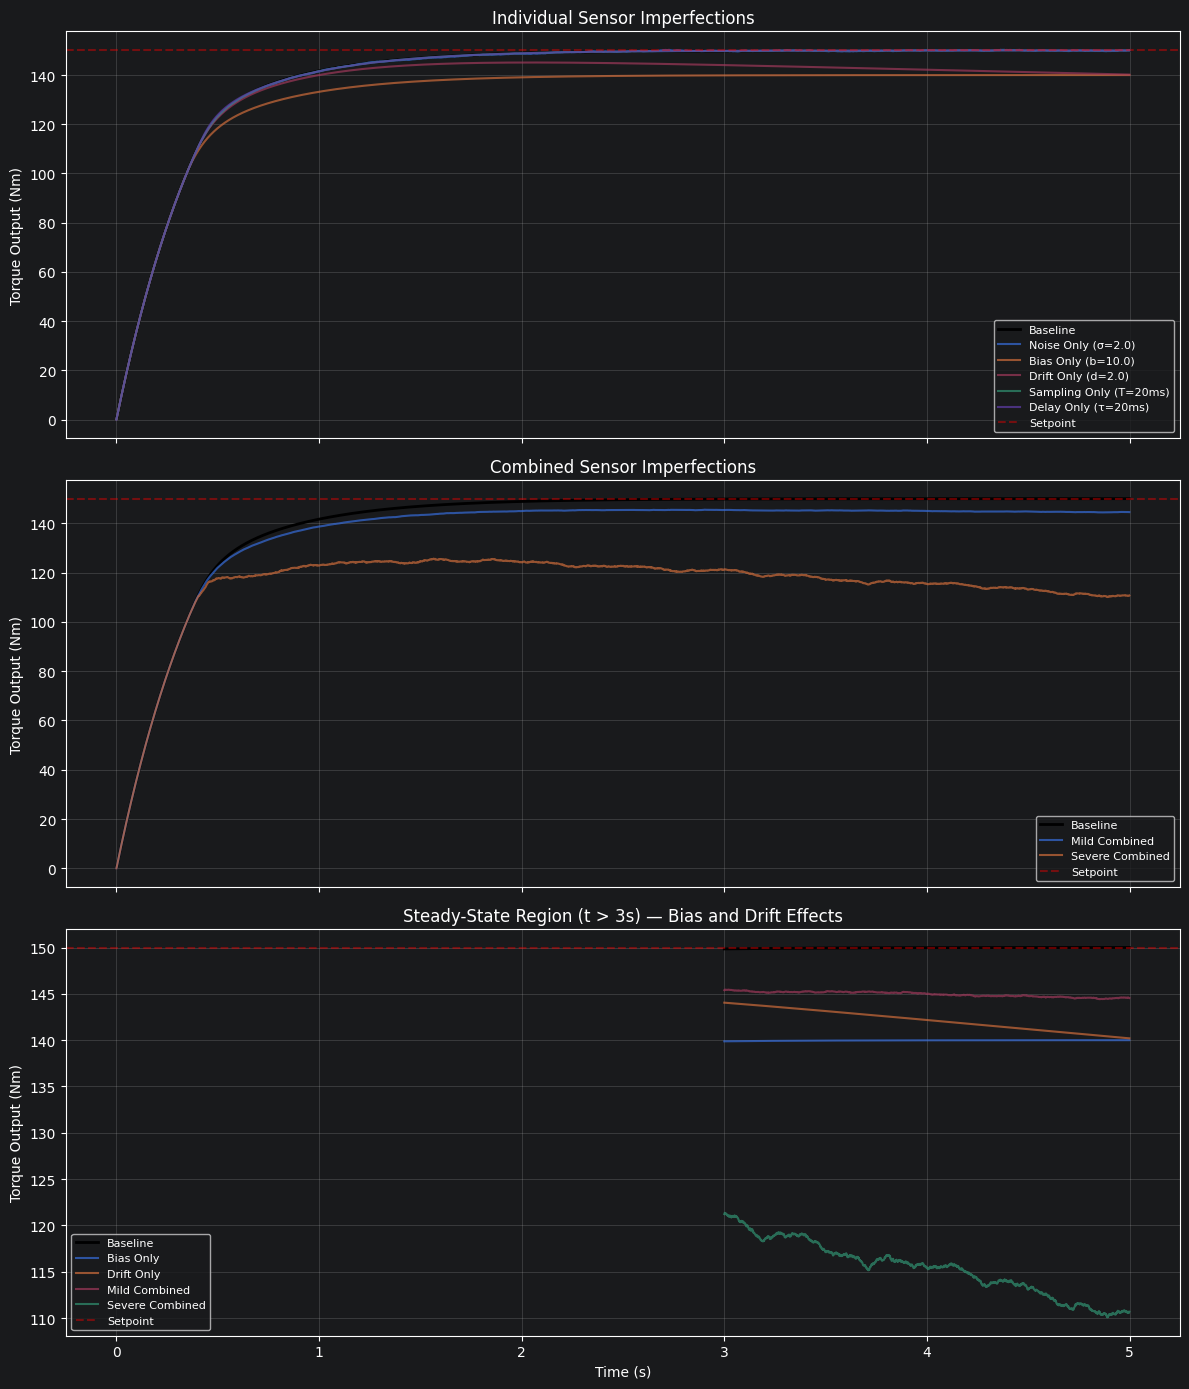

In [20]:
# === Torque Response Overlay ===
# All eight configurations plotted together to visually compare
# how each sensor imperfection affects the torque output.

fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)

# --- Top panel: Individual imperfections ---
axes[0].plot(all_results['Baseline']['time'], all_results['Baseline']['output'],
            color='black', linewidth=2, label='Baseline')
axes[0].plot(all_results['Noise Only']['time'], all_results['Noise Only']['output'],
            alpha=0.7, label='Noise Only (σ=2.0)')
axes[0].plot(all_results['Bias Only']['time'], all_results['Bias Only']['output'],
            alpha=0.7, label='Bias Only (b=10.0)')
axes[0].plot(all_results['Drift Only']['time'], all_results['Drift Only']['output'],
            alpha=0.7, label='Drift Only (d=2.0)')
axes[0].plot(all_results['Sampling Only']['time'], all_results['Sampling Only']['output'],
            alpha=0.7, label='Sampling Only (T=20ms)')
axes[0].plot(all_results['Delay Only']['time'], all_results['Delay Only']['output'],
            alpha=0.7, label='Delay Only (τ=20ms)')
axes[0].axhline(y=setpoint, color='red', linestyle='--', alpha=0.4, label='Setpoint')
axes[0].set_ylabel('Torque Output (Nm)')
axes[0].set_title('Individual Sensor Imperfections')
axes[0].legend(loc='lower right', fontsize=8)
axes[0].grid(True, alpha=0.3)

# --- Middle panel: Combined imperfections ---
axes[1].plot(all_results['Baseline']['time'], all_results['Baseline']['output'],
            color='black', linewidth=2, label='Baseline')
axes[1].plot(all_results['Mild Combined']['time'], all_results['Mild Combined']['output'],
            alpha=0.7, label='Mild Combined')
axes[1].plot(all_results['Severe Combined']['time'], all_results['Severe Combined']['output'],
            alpha=0.7, label='Severe Combined')
axes[1].axhline(y=setpoint, color='red', linestyle='--', alpha=0.4, label='Setpoint')
axes[1].set_ylabel('Torque Output (Nm)')
axes[1].set_title('Combined Sensor Imperfections')
axes[1].legend(loc='lower right', fontsize=8)
axes[1].grid(True, alpha=0.3)

# --- Bottom panel: Zoomed steady-state region (last 2 seconds) ---
for label in ['Baseline', 'Bias Only', 'Drift Only', 'Mild Combined', 'Severe Combined']:
    results = all_results[label]
    # Last 2 seconds
    mask = results['time'] >= 3.0
    style = dict(linewidth=2, color='black') if label == 'Baseline' else dict(alpha=0.7)
    axes[2].plot(results['time'][mask], results['output'][mask], label=label, **style)
axes[2].axhline(y=setpoint, color='red', linestyle='--', alpha=0.4, label='Setpoint')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Torque Output (Nm)')
axes[2].set_title('Steady-State Region (t > 3s) — Bias and Drift Effects')
axes[2].legend(loc='best', fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 9.2 RMS Error Comparison

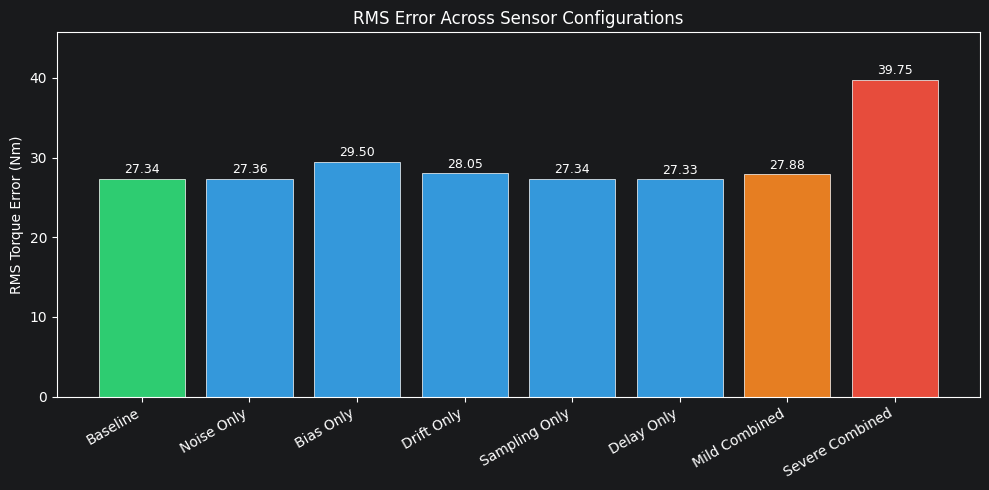

In [21]:
# === RMS Error Bar Chart ===
# Side-by-side comparison of RMS torque error across all configurations.

labels = list(all_metrics.keys())
rms_values = [all_metrics[l]['rms_error'] for l in labels]

# Color baseline differently
colors = ['#2ecc71'] + ['#3498db'] * 5 + ['#e67e22', '#e74c3c']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels, rms_values, color=colors, edgecolor='white', linewidth=0.5)

# Add value labels on bars
for bar, val in zip(bars, rms_values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('RMS Torque Error (Nm)')
ax.set_title('RMS Error Across Sensor Configurations')
ax.set_ylim(0, max(rms_values) * 1.15)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 10. Grid Search Optimization

In [22]:
# === Full Grid Search Optimization ===
# Sweep all five sensor parameters across their defined ranges.
# Total combinations: 5^5 = 3,125 simulations.

dt = 0.001
duration = 5.0
setpoint = 150.0

# --- Define parameter ranges ---
param_ranges = {
    'noise_std':       [0, 0.5, 1, 2, 3, 4, 5],
    'bias':            [0, 2.5, 5, 7.5, 10, 12.5, 15],
    'drift_rate':      [0, 0.5, 1, 2, 3, 4, 5],
    'sampling_period': [0.001, 0.005, 0.01, 0.02, 0.03, 0.04, 0.05],
    'delay_steps':     [0, 5, 10, 20, 30, 40, 50],
}

total = 1
for v in param_ranges.values():
    total *= len(v)
print(f"Total combinations: {total}")

# --- Run grid search ---
plant_template = PowertrainModel(gain=200.0, time_constant=0.5)
pid_template = PIDController(kp=kp_imc, ki=ki_imc, kd=kd_imc, setpoint=setpoint)
engine = SimulationEngine(plant_template, pid_template, sensor=None, dt=dt, duration=duration)

optimizer = GridSearchOptimizer(param_ranges, engine)
optimizer.run_search()

# --- Results ---
results_df = optimizer.get_results_dataframe()
optimal = optimizer.get_optimal()

print(f"\nGrid search complete. {len(results_df)} configurations evaluated.")
print(f"\nOptimal Configuration (lowest RMS error):")
for key, val in optimal.items():
    print(f"  {key}: {val}")

print(f"\nRMS Error Range: {results_df['rms_error'].min():.4f} — {results_df['rms_error'].max():.4f} Nm")
print(f"Top 5 configurations:")
print(results_df.nsmallest(5, 'rms_error').to_string(index=False))

Total combinations: 16807
Grid search: 16807 combinations to evaluate
  Progress: 1680/16807 (10%)
  Progress: 3360/16807 (20%)
  Progress: 5040/16807 (30%)
  Progress: 6720/16807 (40%)
  Progress: 8400/16807 (50%)
  Progress: 10080/16807 (60%)
  Progress: 11760/16807 (70%)
  Progress: 13440/16807 (80%)
  Progress: 15120/16807 (90%)
  Progress: 16800/16807 (100%)
  Progress: 16807/16807 (100%)

Grid search complete. Best RMS error: 27.2911 Nm

Grid search complete. 16807 configurations evaluated.

Optimal Configuration (lowest RMS error):
  noise_std: 0.0
  bias: 0.0
  drift_rate: 0.0
  sampling_period: 0.03
  delay_steps: 40.0
  rms_error: 27.291054881885103
  overshoot: 0.0
  settling_time: 1.534

RMS Error Range: 27.2911 — 39.9126 Nm
Top 5 configurations:
 noise_std  bias  drift_rate  sampling_period  delay_steps  rms_error  overshoot  settling_time
       0.0   0.0         0.0             0.03           40  27.291055   0.000000          1.534
       1.0   0.0         0.0           

## 11. Results Analysis and Visualization

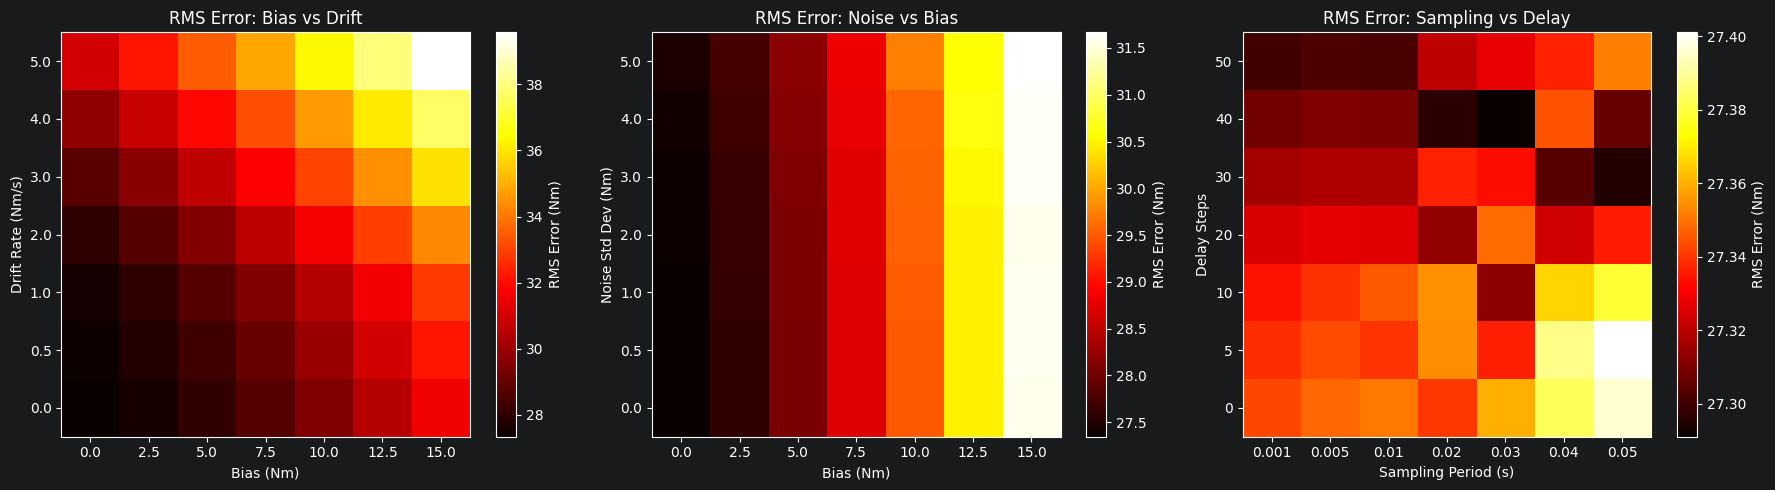

Bias vs Drift  — RMS range: 27.34 to 39.57 Nm
Noise vs Bias  — RMS range: 27.34 to 31.67 Nm
Sampling vs Delay — RMS range: 27.29 to 27.40 Nm


In [23]:
# === Grid Search Heatmaps ===
# 2D slices through the 5D parameter space. For each heatmap, three
# parameters are fixed at neutral values while two are varied.
# Neutral: noise_std=0, bias=0, drift_rate=0, sampling_period=0.001, delay_steps=0

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Heatmap 1: Bias vs Drift (most impactful pair) ---
slice_1 = results_df[
    (results_df['noise_std'] == 0) &
    (results_df['sampling_period'] == 0.001) &
    (results_df['delay_steps'] == 0)
]
pivot_1 = slice_1.pivot_table(index='drift_rate', columns='bias', values='rms_error')
im1 = axes[0].imshow(pivot_1.values, aspect='auto', origin='lower', cmap='hot')
axes[0].set_xticks(range(len(pivot_1.columns)))
axes[0].set_xticklabels([f'{v:.1f}' for v in pivot_1.columns])
axes[0].set_yticks(range(len(pivot_1.index)))
axes[0].set_yticklabels([f'{v:.1f}' for v in pivot_1.index])
axes[0].set_xlabel('Bias (Nm)')
axes[0].set_ylabel('Drift Rate (Nm/s)')
axes[0].set_title('RMS Error: Bias vs Drift')
plt.colorbar(im1, ax=axes[0], label='RMS Error (Nm)')

# --- Heatmap 2: Noise vs Bias ---
slice_2 = results_df[
    (results_df['drift_rate'] == 0) &
    (results_df['sampling_period'] == 0.001) &
    (results_df['delay_steps'] == 0)
]
pivot_2 = slice_2.pivot_table(index='noise_std', columns='bias', values='rms_error')
im2 = axes[1].imshow(pivot_2.values, aspect='auto', origin='lower', cmap='hot')
axes[1].set_xticks(range(len(pivot_2.columns)))
axes[1].set_xticklabels([f'{v:.1f}' for v in pivot_2.columns])
axes[1].set_yticks(range(len(pivot_2.index)))
axes[1].set_yticklabels([f'{v:.1f}' for v in pivot_2.index])
axes[1].set_xlabel('Bias (Nm)')
axes[1].set_ylabel('Noise Std Dev (Nm)')
axes[1].set_title('RMS Error: Noise vs Bias')
plt.colorbar(im2, ax=axes[1], label='RMS Error (Nm)')

# --- Heatmap 3: Sampling Period vs Delay ---
slice_3 = results_df[
    (results_df['noise_std'] == 0) &
    (results_df['bias'] == 0) &
    (results_df['drift_rate'] == 0)
]
pivot_3 = slice_3.pivot_table(index='delay_steps', columns='sampling_period', values='rms_error')
im3 = axes[2].imshow(pivot_3.values, aspect='auto', origin='lower', cmap='hot')
axes[2].set_xticks(range(len(pivot_3.columns)))
axes[2].set_xticklabels([f'{v}' for v in pivot_3.columns])
axes[2].set_yticks(range(len(pivot_3.index)))
axes[2].set_yticklabels([f'{int(v)}' for v in pivot_3.index])
axes[2].set_xlabel('Sampling Period (s)')
axes[2].set_ylabel('Delay Steps')
axes[2].set_title('RMS Error: Sampling vs Delay')
plt.colorbar(im3, ax=axes[2], label='RMS Error (Nm)')

plt.tight_layout()
plt.show()

# Print the RMS range for each slice to confirm contrast
print(f"Bias vs Drift  — RMS range: {pivot_1.values.min():.2f} to {pivot_1.values.max():.2f} Nm")
print(f"Noise vs Bias  — RMS range: {pivot_2.values.min():.2f} to {pivot_2.values.max():.2f} Nm")
print(f"Sampling vs Delay — RMS range: {pivot_3.values.min():.2f} to {pivot_3.values.max():.2f} Nm")

### 11.1 3D Surface Plot

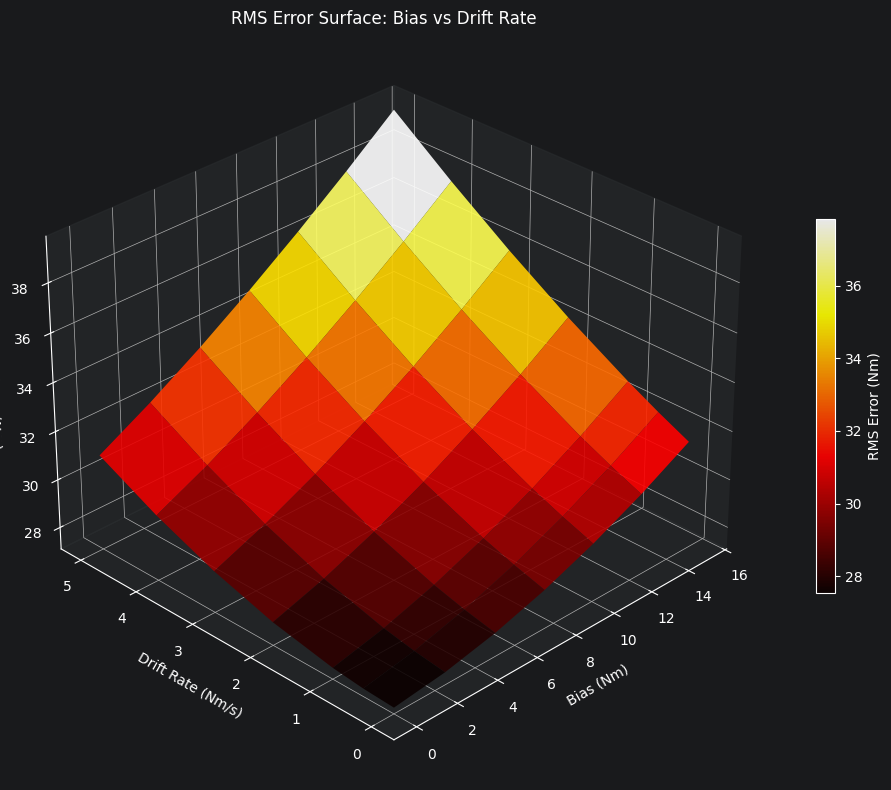

In [24]:
# === 3D Surface Plot: Bias vs Drift vs RMS Error ===
# The most impactful parameter pair visualized as a surface.
# Other parameters fixed at neutral values.

from mpl_toolkits.mplot3d import Axes3D

slice_surface = results_df[
    (results_df['noise_std'] == 0) &
    (results_df['sampling_period'] == 0.001) &
    (results_df['delay_steps'] == 0)
]

pivot_surface = slice_surface.pivot_table(
    index='drift_rate', columns='bias', values='rms_error'
)

bias_vals = pivot_surface.columns.values
drift_vals = pivot_surface.index.values
B, D = np.meshgrid(bias_vals, drift_vals)
Z = pivot_surface.values

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(B, D, Z, cmap='hot', edgecolor='none', alpha=0.9)

ax.set_xlabel('Bias (Nm)')
ax.set_ylabel('Drift Rate (Nm/s)')
ax.set_zlabel('RMS Error (Nm)')
ax.set_title('RMS Error Surface: Bias vs Drift Rate')
ax.view_init(elev=30, azim=225)

plt.colorbar(surf, ax=ax, shrink=0.5, label='RMS Error (Nm)')
plt.tight_layout()
plt.show()

In [25]:
print(all_results["Severe Combined"]["output"][-1])

110.69209739694566
